# Data analysis of Ciqual dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## More info about the data
* Food composition values are always in unit of 100g, so we can simplify the title
* When an average content is unknown, a dash appears in place of the value. Users ofcomposition data must not treat them as zeros. The proportion of missing average contents in the Anses-Ciqual 2025 table is 30%. This fraction of missing data is normal in the field.
* Traces. In some cases, a component is detected analytically but cannot be precisely quantified. The analytical result is then reported as 'traces'. The term 'traces' may also be used in the absence of analysis when Ciqual considersthat the average content of a component in a food is very low but cannot beconsidered zero. Values below 0.00001 are replaced by 'traces'.

Energy. For all foods on the Anses-Ciqual table, the energy value was calculated using thefollowing coefficients:

\- for lipids: 37 kJ/g (9 kcal/g);\
\- for alcohol (ethanol): 29 kJ/g (7 kcal/g);\
\- for proteins: 17 kJ/g (4 kcal/g);\
\- for carbohydrates (except polyols): 17 kJ/g (4 kcal/g);\
\- for organic acids: 13 k/g (3 kcal/g);\
\- for polyols: 10 k/g (2.4 kcal/g);\
\- for dietary fibres: 8 kJ/g (2 kcal/g).

In [25]:
df = pd.read_excel('Table Ciqual 2025_ENG_2025_11_03.xlsx')
df

d:\anaconda\anaconda3\envs\erdos_ds_environment\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy,\nRegulation\nEU No\n1169\n2011 (kJ\n100g)",...,Vitamin\nB2 or\nRiboflavin\n(mg\n100g),Vitamin\nB3 or\nNiacin\n(mg\n100g),Vitamin B5\nor\nPantothenic\nacid (mg\n100g),Vitamin\nB6 (mg\n100g),"Vitamin B9 or\ntotal folates,\ndietary folate\nequivalents, DFE\n(µg\n100g)",Vitamin\nB9 or\ntotal\nfolates\n(µg\n100g),Intrinsic\nfolate\n(µg\n100 g),Folic acid\n(enrichment)\n(µg\n100g),Vitamin\nB12\n(µg\n100g),Jones\nfactor
0,0,0,0,-,-,-,24999,Dessert (average),NaN,1070,...,"0,16","0,21","0,38","0,044",-,-,-,-,"0,18",6.25
1,1,101,0,starters and dishes,mixed salads,-,8406,"Salad of pig's snout, with sauce, prepacked",NaN,712,...,-,-,-,-,-,-,-,-,-,6.25
2,1,101,0,starters and dishes,mixed salads,-,8407,"Salad of saveloy, with sauce, prepacked",NaN,1070,...,-,-,-,-,-,-,-,-,-,6.25
3,1,101,0,starters and dishes,mixed salads,-,25600,"Celeriac salad, with remoulade sauce, prepacked",NaN,469,...,"0,029","< 0,1","0,49","0,089",-,"6,39",-,-,"< 0,08",6.25
4,1,101,0,starters and dishes,mixed salads,-,25601,"Tuna salad, with vegetables, canned",NaN,489,...,"0,053","4,45","< 0,16","0,29",-,31,-,-,"1,45",6.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3479,11,1103,0,baby food,baby deserts,-,13166,"Dairy dessert for baby, with sugar(s), plain o...",NaN,408,...,"0,11","0,12","0,26","0,029",-,"9,06",-,-,"0,2",6.38
3480,11,1104,0,baby food,baby biscuits and cereals,-,13167,Baby instant cereal (powder to be reconstitute...,NaN,1670,...,"0,04","5,02","1,33","0,38",-,100,-,-,"0,44",6.25
3481,11,1104,0,baby food,baby biscuits and cereals,-,13168,Baby instant cereal (powder to be reconstitute...,NaN,1660,...,"0,04","4,43","1,58","0,29",-,"86,5",-,-,"0,29",6.25
3482,11,1104,0,baby food,baby biscuits and cereals,-,24689,Baby biscuit,NaN,1850,...,"0,62","5,9","4,69","0,66",-,"31,1",-,-,"0,28",6.25


In [26]:
# Simplify column names: remove newlines, remove per-100g units, clean up whitespace
rename_map = {}
for col in df.columns:
    new = col.replace('\n', ' ')          # replace newlines with spaces
    new = new.replace('(g 100g)', '(g)')
    new = new.replace('(mg 100g)', '(mg)')
    new = new.replace('(µg 100mg)', '(µg)')  # col 62 has typo in original data
    new = new.replace('(µg 100g)', '(µg)')
    new = new.replace('(µg 100 g)', '(µg)')
    new = new.replace('(kJ 100g)', '(kJ)')
    new = new.replace('(kcal 100g)', '(kcal)')
    new = ' '.join(new.split())            # collapse multiple spaces
    rename_map[col] = new

df.rename(columns=rename_map, inplace=True)

# Show the new column names
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")
df.head()

0: alim_grp_code
1: alim_ssgrp_code
2: alim_ssssgrp_code
3: alim_grp_nom_eng
4: alim_ssgrp_nom_eng
5: alim_ssssgrp_nom_eng
6: alim_code
7: alim_nom_eng
8: alim_nom_sci
9: Energy, Regulation EU No 1169 2011 (kJ)
10: Energy, Regulation EU No 1169 2011 (kcal)
11: Energy, N x Jones' factor, with fibres (kJ)
12: Energy, N x Jones' factor, with fibres (kcal)
13: Water (g)
14: Protein (g)
15: Protein, crude, N x 6.25 (g)
16: Carbohydrate (g)
17: Fat (g)
18: Sugars (g)
19: Fructose (g)
20: Galactose (g)
21: Glucose (g)
22: Lactose (g)
23: Maltose (g)
24: Sucrose (g)
25: Starch (g)
26: Fibres (g)
27: Polyols (g)
28: Ash (g)
29: Alcohol (g)
30: Organic acids (g)
31: FA saturated (g)
32: FA mono (g)
33: FA poly (g)
34: FA 4:0 (g)
35: FA 6:0 (g)
36: FA 8:0 (g)
37: FA 10:0 (g)
38: FA 12:0 (g)
39: FA 14:0 (g)
40: FA 16:0 (g)
41: FA 18:0 (g)
42: FA 18:1 n-9 cis (g)
43: FA 18:2 9c,12c (n-6) (g)
44: FA 18:3 c9,c12,c15 (n-3) (g)
45: FA 20:4 5c,8c,11c,14c (n-6) (g)
46: FA 20:5 5c,8c,11c,14c,17c (n-3) EPA

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, Regulation EU No 1169 2011 (kJ)",...,Vitamin B2 or Riboflavin (mg),Vitamin B3 or Niacin (mg),Vitamin B5 or Pantothenic acid (mg),Vitamin B6 (mg),"Vitamin B9 or total folates, dietary folate equivalents, DFE (µg)",Vitamin B9 or total folates (µg),Intrinsic folate (µg),Folic acid (enrichment) (µg),Vitamin B12 (µg),Jones factor
0,0,0,0,-,-,-,24999,Dessert (average),NaN,1070,...,"0,16","0,21","0,38","0,044",-,-,-,-,"0,18",6.25
1,1,101,0,starters and dishes,mixed salads,-,8406,"Salad of pig's snout, with sauce, prepacked",NaN,712,...,-,-,-,-,-,-,-,-,-,6.25
2,1,101,0,starters and dishes,mixed salads,-,8407,"Salad of saveloy, with sauce, prepacked",NaN,1070,...,-,-,-,-,-,-,-,-,-,6.25
3,1,101,0,starters and dishes,mixed salads,-,25600,"Celeriac salad, with remoulade sauce, prepacked",NaN,469,...,"0,029","< 0,1","0,49","0,089",-,"6,39",-,-,"< 0,08",6.25
4,1,101,0,starters and dishes,mixed salads,-,25601,"Tuna salad, with vegetables, canned",NaN,489,...,"0,053","4,45","< 0,16","0,29",-,31,-,-,"1,45",6.25


In [27]:
df.drop(columns=["alim_nom_sci",
                "Energy, Regulation EU No 1169 2011 (kJ)",
                "Energy, N x Jones' factor, with fibres (kJ)"], 
                inplace=True)
for i, col in enumerate(df.columns):
    print(f"{i}: {col}") 

0: alim_grp_code
1: alim_ssgrp_code
2: alim_ssssgrp_code
3: alim_grp_nom_eng
4: alim_ssgrp_nom_eng
5: alim_ssssgrp_nom_eng
6: alim_code
7: alim_nom_eng
8: Energy, Regulation EU No 1169 2011 (kcal)
9: Energy, N x Jones' factor, with fibres (kcal)
10: Water (g)
11: Protein (g)
12: Protein, crude, N x 6.25 (g)
13: Carbohydrate (g)
14: Fat (g)
15: Sugars (g)
16: Fructose (g)
17: Galactose (g)
18: Glucose (g)
19: Lactose (g)
20: Maltose (g)
21: Sucrose (g)
22: Starch (g)
23: Fibres (g)
24: Polyols (g)
25: Ash (g)
26: Alcohol (g)
27: Organic acids (g)
28: FA saturated (g)
29: FA mono (g)
30: FA poly (g)
31: FA 4:0 (g)
32: FA 6:0 (g)
33: FA 8:0 (g)
34: FA 10:0 (g)
35: FA 12:0 (g)
36: FA 14:0 (g)
37: FA 16:0 (g)
38: FA 18:0 (g)
39: FA 18:1 n-9 cis (g)
40: FA 18:2 9c,12c (n-6) (g)
41: FA 18:3 c9,c12,c15 (n-3) (g)
42: FA 20:4 5c,8c,11c,14c (n-6) (g)
43: FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g)
44: FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g)
45: Cholesterol (mg)
46: Salt (g)
47: Calcium (mg)
48: C

## Data cleaning
The numeric columns contain special string values that need handling:
* `"-"` means unknown/missing → convert to `NaN` (~85k cells, ~30% of data)
* `"traces"` means detected but too small to quantify → convert to `0`
* `"< 0,16"` means below a threshold → strip `<` and use the value as an upper-bound estimate
* Commas are used as decimal separators (French format) → replace with dots
* All numeric columns are stored as strings → convert to `float`

In [28]:
# Numeric columns start after the text/identifier columns (index 8 onward after dropping 3 cols)
numeric_cols = df.columns[8:]

def clean_numeric(series):
    """Clean a column of French-formatted numeric strings into proper floats."""
    if series.dtype in ['float64', 'int64']:
        return series
    s = series.astype(str)
    s = s.replace('-', np.nan)
    s = s.replace('traces', '0')
    s = s.str.replace(r'^<\s*', '', regex=True)
    s = s.str.replace(',', '.', regex=False)
    return pd.to_numeric(s, errors='coerce')

df[numeric_cols] = df[numeric_cols].apply(clean_numeric)

print(f"Shape: {df.shape}")
print(f"\nDtypes of first few numeric columns:")
print(df[numeric_cols[:5]].dtypes)
print(f"\nSample values:")
df[numeric_cols[:5]].head()

Shape: (3484, 81)

Dtypes of first few numeric columns:
Energy, Regulation EU No 1169 2011 (kcal)        float64
Energy, N x Jones' factor, with fibres (kcal)    float64
Water (g)                                        float64
Protein (g)                                      float64
Protein, crude, N x 6.25 (g)                     float64
dtype: object

Sample values:


,"Energy, Regulation EU No 1169 2011 (kcal)","Energy, N x Jones' factor, with fibres (kcal)",Water (g),Protein (g),"Protein, crude, N x 6.25 (g)"
0,255.0,255.0,49.9,4.41,4.39
1,172.0,172.0,75.5,8.51,8.51
2,259.0,259.0,NaN,7.60,7.60
3,114.0,114.0,81.5,0.94,0.94
4,117.0,117.0,76.5,9.15,9.15


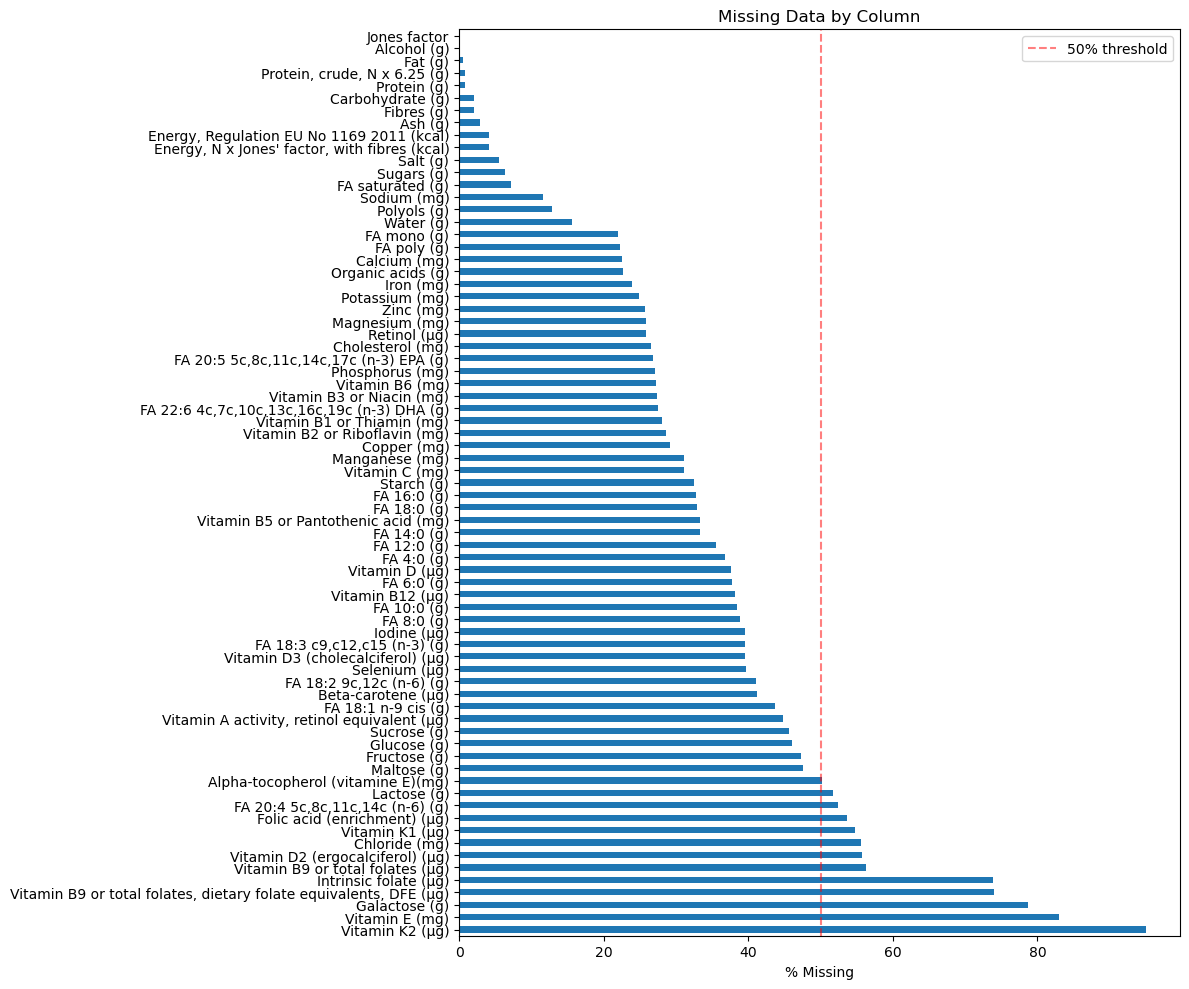


Columns with >50% missing: 13
Columns with >80% missing: 2


In [ ]:
# Visualize missing data percentage per column
missing_pct = df[numeric_cols].isna().mean() * 100
missing_pct_sorted = missing_pct.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
missing_pct_sorted.plot(kind='barh', ax=ax)
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nColumns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns with >80% missing: {(missing_pct > 80).sum()}")

In [36]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

No dupicate rows.

## Exploratory Data Analysis (EDA)

Focusing on the features relevant to our two prediction targets:

**Nutri-Score** uses: Energy (kcal), Sugars, Saturated fat, Salt (negative) + Fibre, Protein (positive)
*Note: Fruit & vegetables % is not in the dataset*

**NRF 9.3** uses: Protein, Fibre, Vit A, Vit C, Vit E, Ca, Fe, K, Mg (positive) — Sat fat, Added sugar, Sodium (negative)
*Note: "Added sugar" is not in the dataset, only total Sugars*

In [37]:
# Key features for both scores
key_features = [
    "Energy, Regulation EU No 1169 2011 (kcal)",
    "Protein (g)", "Sugars (g)", "FA saturated (g)", "Fibres (g)",
    "Salt (g)", "Sodium (mg)",
    "Vitamin A activity, retinol equivalent (µg)", "Vitamin C (mg)",
    "Vitamin E (mg)", "Calcium (mg)", "Iron (mg)",
    "Potassium (mg)", "Magnesium (mg)"
]

df[key_features].describe().round(2)

,"Energy, Regulation EU No 1169 2011 (kcal)",Protein (g),Sugars (g),FA saturated (g),Fibres (g),Salt (g),Sodium (mg),"Vitamin A activity, retinol equivalent (µg)",Vitamin C (mg),Vitamin E (mg),Calcium (mg),Iron (mg),Potassium (mg),Magnesium (mg)
count,3341.00,3455.00,3261.00,3236.00,3414.00,3294.00,3082.00,1922.00,2398.00,595.00,2700.00,2653.00,2617.00,2585.00
mean,207.02,9.11,7.23,4.06,2.37,0.96,393.39,108.92,10.82,1.81,105.23,2.33,287.61,41.38
std,172.01,9.10,13.25,7.17,5.15,4.60,1959.21,673.75,78.59,4.55,633.99,8.68,484.71,118.49
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,72.60,1.38,0.10,0.13,0.00,0.04,15.00,0.91,0.50,0.10,12.00,0.25,115.00,10.00
50%,163.00,6.35,1.95,1.27,1.00,0.22,82.00,10.10,1.50,0.55,28.65,0.73,198.00,19.00
75%,311.00,15.50,7.17,4.82,2.60,1.06,402.00,48.75,6.48,1.63,77.00,1.76,321.00,31.40
max,900.00,86.90,99.70,94.60,79.00,97.80,39100.00,13800.00,2850.00,61.70,30400.00,205.00,10400.00,2660.00


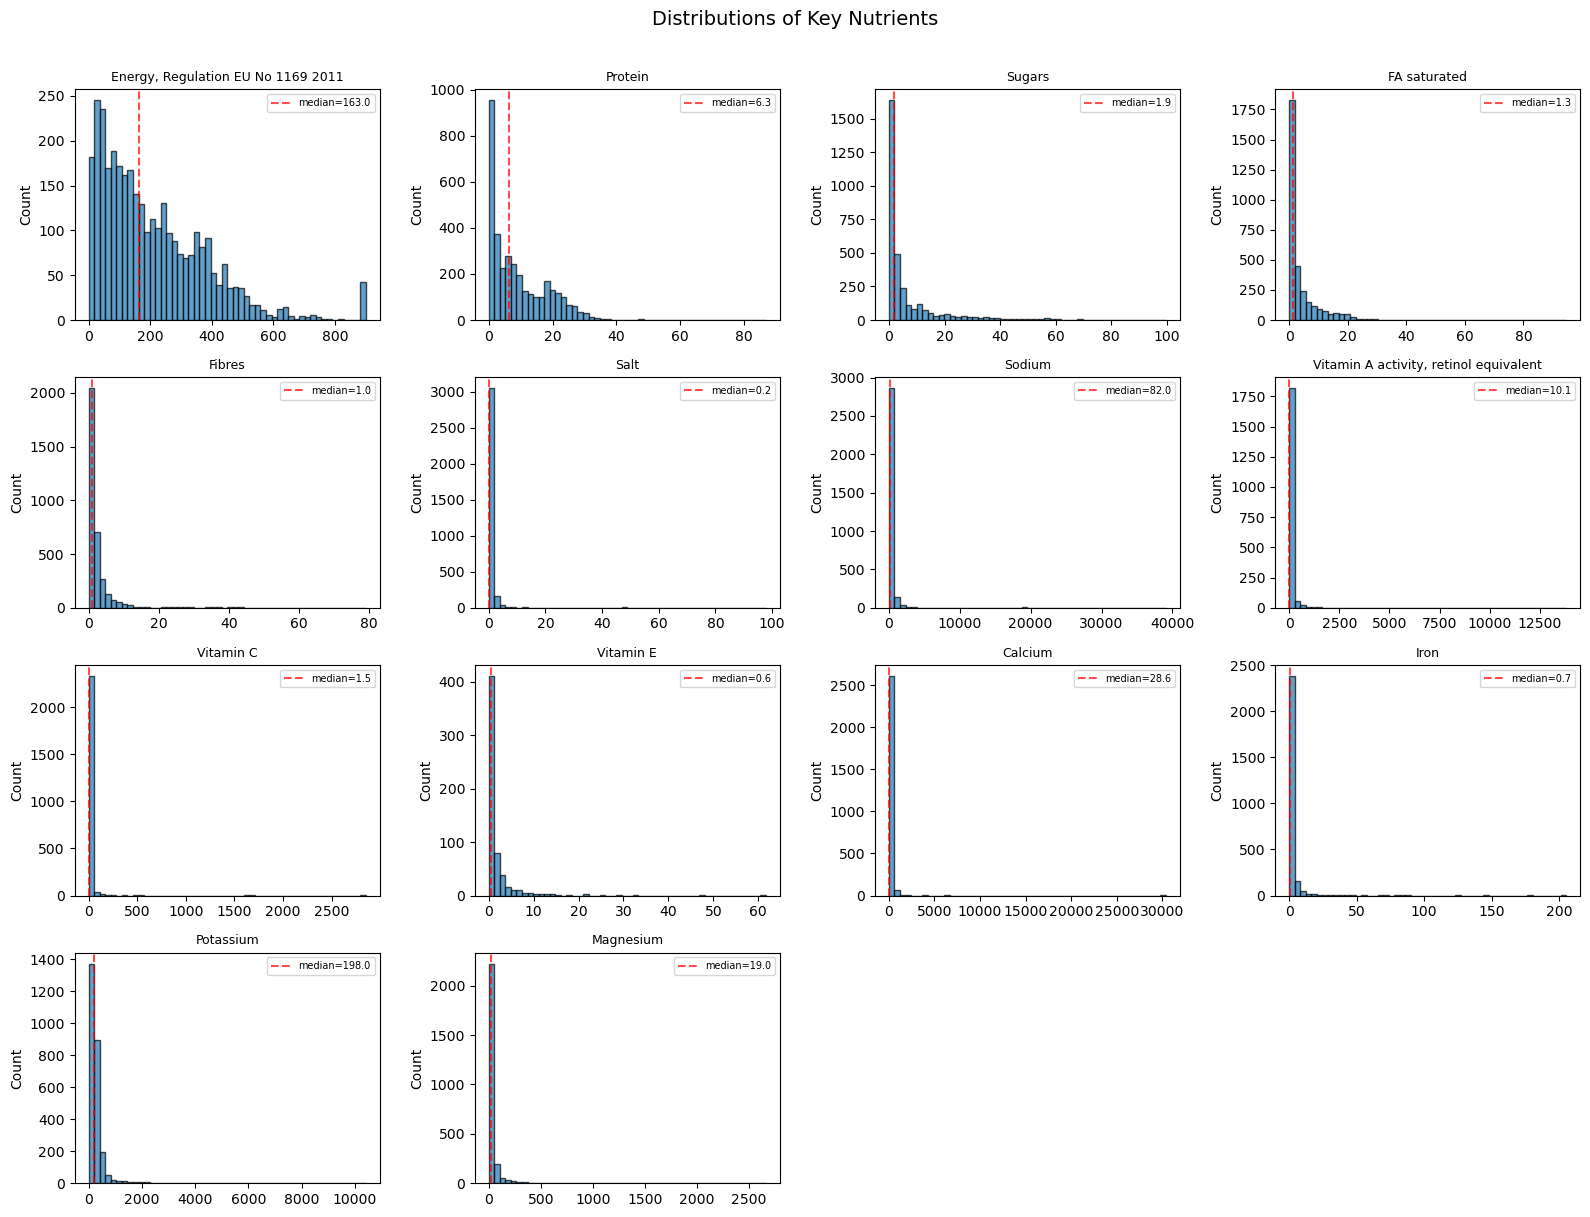

In [38]:
# Distributions of key nutrients (Nutri-Score + NRF 9.3 features)
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(col.split('(')[0].strip(), fontsize=9)
    ax.set_ylabel('Count')
    # Add median line
    median = data.median()
    ax.axvline(median, color='red', linestyle='--', alpha=0.7, label=f'median={median:.1f}')
    ax.legend(fontsize=7)

# Hide unused subplots
for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Key Nutrients', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Some elements has extremly large value. This is real data. For example, salt is included in the table, so the salt value is definitely highest. These may not be usual food, but they are real data.

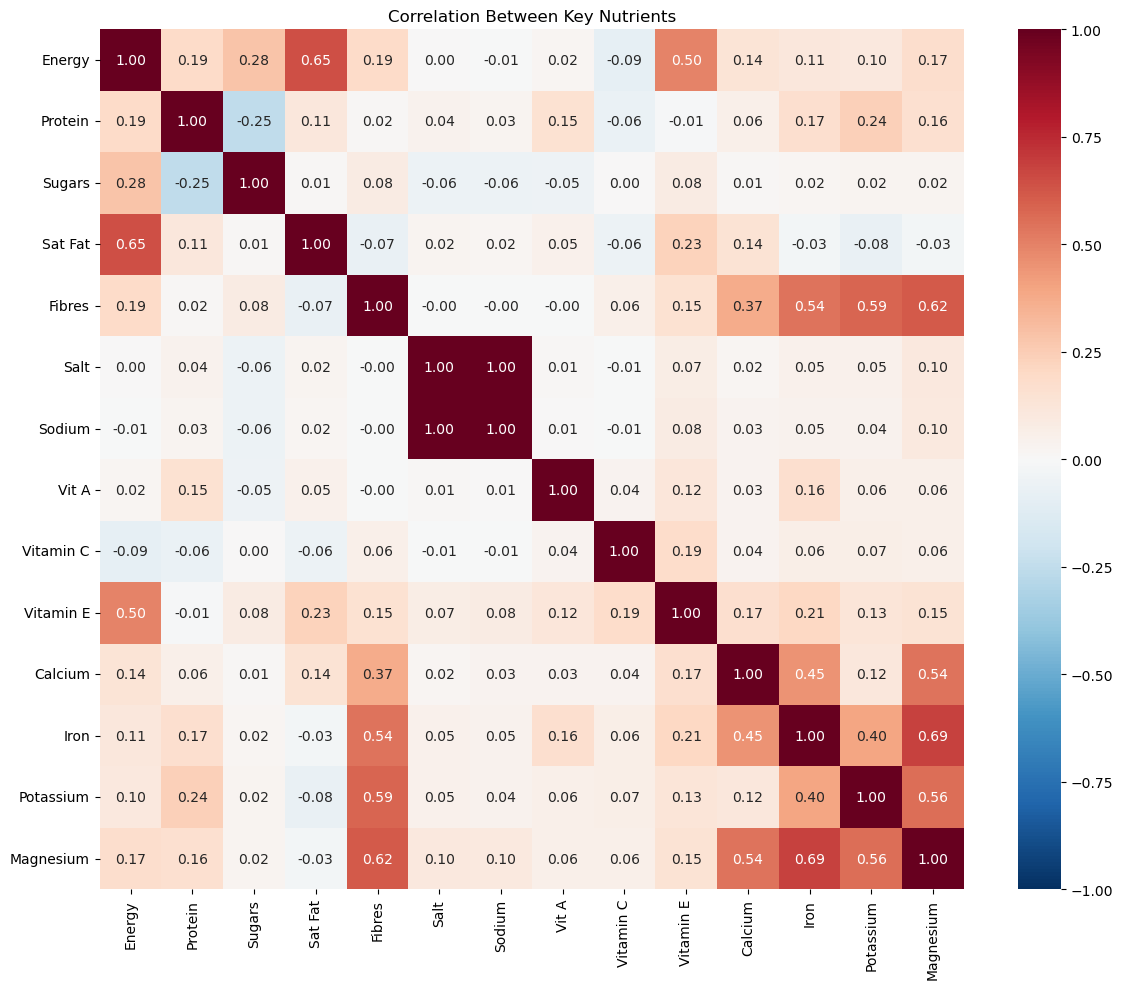

In [39]:
# Correlation heatmap of key features
corr = df[key_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
# Use short labels for readability
short_labels = [col.split('(')[0].strip().replace('Energy, Regulation EU No 1169 2011', 'Energy')
                .replace('Vitamin A activity, retinol equivalent', 'Vit A')
                .replace('FA saturated', 'Sat Fat')
                for col in key_features]

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=short_labels, yticklabels=short_labels, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Between Key Nutrients')
plt.tight_layout()
plt.show()

Several observation from heatmap:
* Sodium and Salt always comes with each other, which is obvious.
* Sat fat usually comes with Energy, because fat has energy 9 kcal/g, with the most contribution to energy.
* Fibers come with Mg, K and Fe. Mg with Ca, Fe and K. This should mean foods higher in fiber tend to also have higher amounts of those minerals.Those nutrients tend to co-occur in similar foods.
* Sugar has negative correlation with protein. This makes sense, because high sugar food are usually drinks, candy, etc. while protein food are meat, without added sugar.

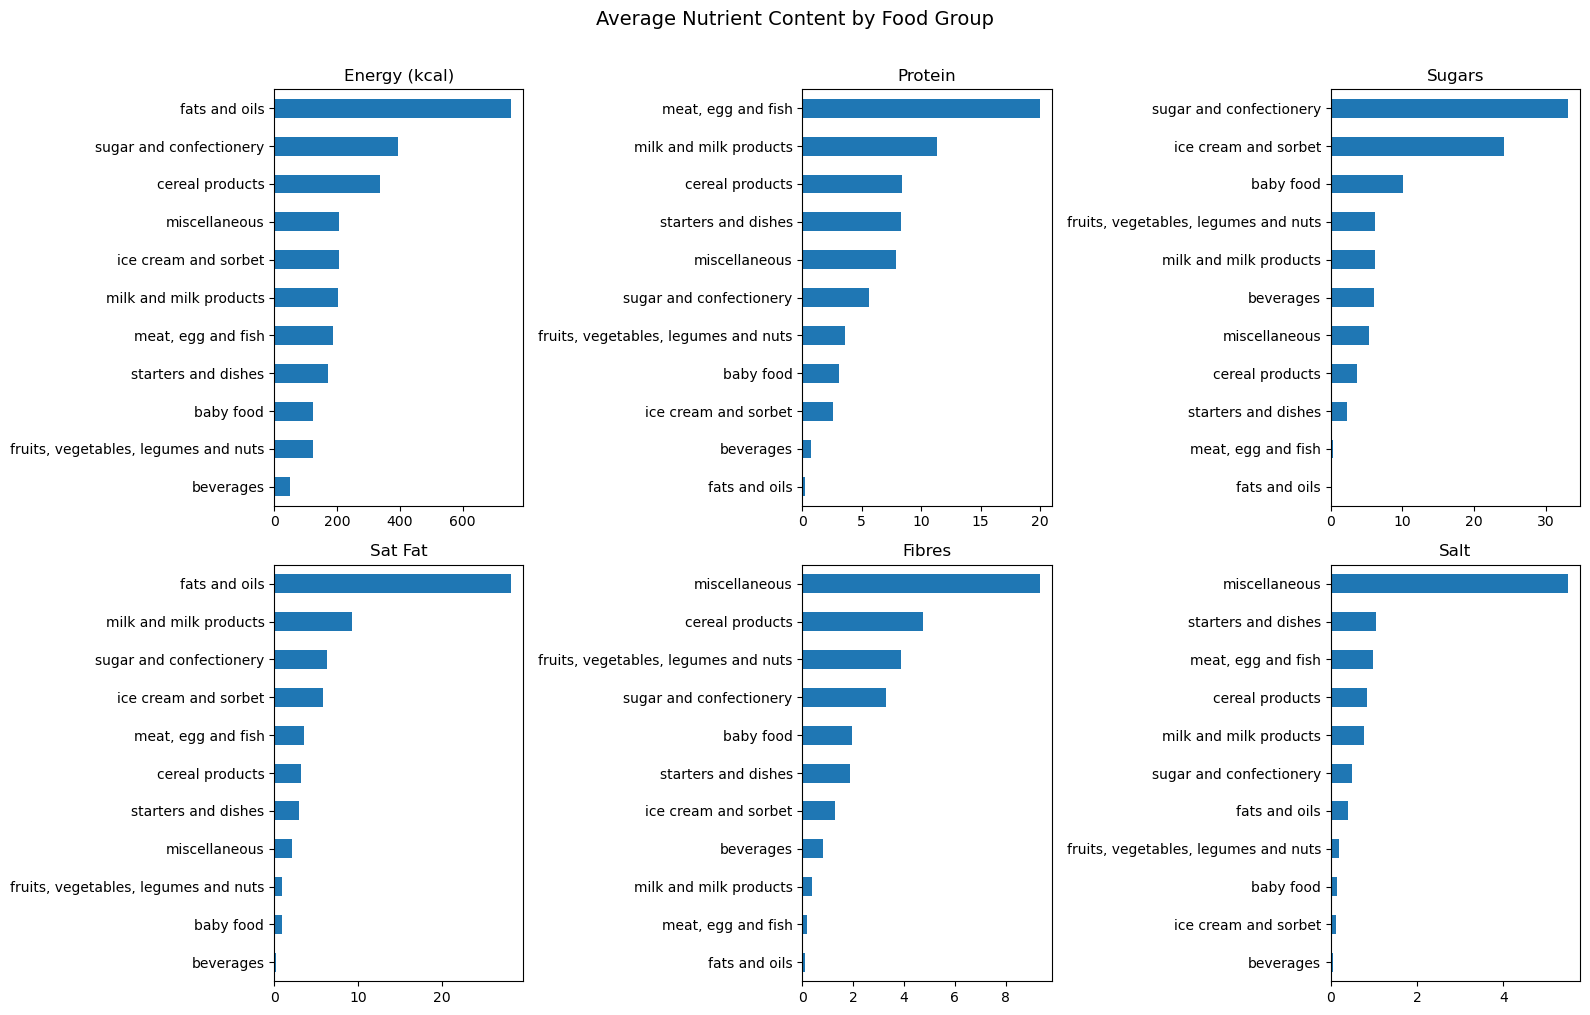

In [40]:
# Average Energy and key macros by food group
group_means = df.groupby('alim_grp_nom_eng')[
    ["Energy, Regulation EU No 1169 2011 (kcal)", "Protein (g)", 
     "Sugars (g)", "FA saturated (g)", "Fibres (g)", "Salt (g)"]
].mean()

# Rename for readability
group_means.columns = ['Energy (kcal)', 'Protein', 'Sugars', 'Sat Fat', 'Fibres', 'Salt']
group_means = group_means.drop('-', errors='ignore')  # drop the '-' group if exists

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(group_means.columns):
    ax = axes.flatten()[i]
    group_means[col].sort_values().plot(kind='barh', ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')

plt.suptitle('Average Nutrient Content by Food Group', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

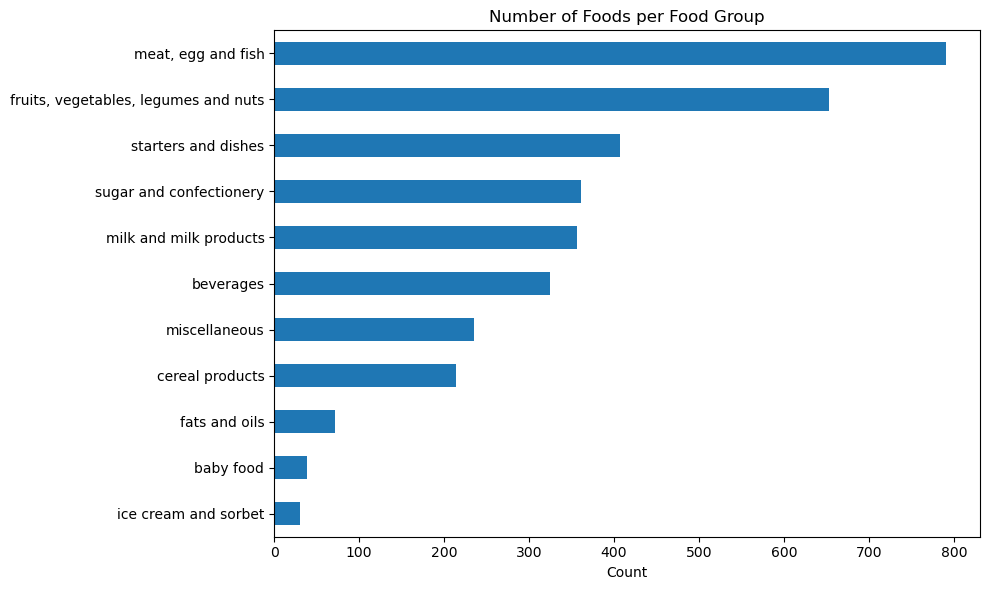

In [41]:
# Number of foods per food group
group_counts = df['alim_grp_nom_eng'].value_counts().drop('-', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 6))
group_counts.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Number of Foods per Food Group')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()
plt.show()